# HVM Obj-SigLIP Sweep Results
Loads all `checkpoints/multihead/hvm_obj_cat/*/best.pt`.

Target: **bbox-crop SigLIP (1152-d)** and **CLIP-short (768-d)** predicted from HVM neural responses with category conditioning.

Sweep axes: `d_model` {64, 128, 256}, `n_layers` {1, 2, 4}, `lr` {1e-3, 3e-4}. `weight_decay` fixed at 1e-2.

In [1]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR, CACHE_DIR

SWEEP_DIR  = CHECKPOINT_DIR / 'multihead' / 'hvm_obj_cat'
SWEEP_AXES = ['d_model', 'n_layers', 'lr']

def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception:
        return None
    row = {**ckpt['args'], **ckpt['metrics'], 'path': str(pt)}
    if 'test_metrics' in ckpt:
        row.update(ckpt['test_metrics'])
    return row

candidates = sorted(SWEEP_DIR.glob('*/best.pt'))
records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc='Loading'):
        row = fut.result()
        if row:
            records.append(row)

df = pd.DataFrame(records)
has_test = 'test_cos_siglip' in df.columns

for col in SWEEP_AXES:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

# keep only runs with fixed nce_weight=0.1
if 'nce_weight' in df.columns and not df.empty:
    df = df[df['nce_weight'] == 0.1].reset_index(drop=True)

SORT_BY = 'val_mean_cos'
show_cols = SWEEP_AXES + ['val_mean_cos', 'val_cos_siglip', 'val_cos_clip',
                           'val_2afc_siglip', 'val_2afc_clip']
show_cols = [c for c in show_cols if c in df.columns]

print(f'{len(df)} runs loaded from {SWEEP_DIR}  |  test metrics: {has_test}')
if not df.empty:
    display(df[show_cols].sort_values(SORT_BY, ascending=False).reset_index(drop=True))
else:
    print('No completed runs yet — submit the sweep job first.')

Loading:   0%|          | 0/26 [00:00<?, ?it/s]

18 runs loaded from /home/yy3658/NeurObjectGen/checkpoints/multihead/hvm_obj_cat  |  test metrics: True


,d_model,n_layers,lr,val_mean_cos,val_cos_siglip,val_cos_clip,val_2afc_siglip,val_2afc_clip
0,64,2,0.0003,0.934491,0.880366,0.988617,0.958177,0.910112
1,64,1,0.0003,0.934228,0.884435,0.984021,0.957803,0.910112
2,64,4,0.0003,0.933462,0.882888,0.984036,0.958177,0.910112
3,64,2,0.0010,0.932764,0.882204,0.983323,0.957054,0.910112
4,64,1,0.0010,0.931282,0.879205,0.983360,0.956804,0.910112
5,64,4,0.0010,0.929496,0.878542,0.980449,0.958926,0.910112
6,128,1,0.0003,0.929454,0.874624,0.984284,0.958177,0.910112
7,128,2,0.0003,0.929401,0.876755,0.982046,0.958052,0.910112
8,256,1,0.0003,0.929292,0.874027,0.984558,0.955805,0.910112
9,128,2,0.0010,0.926722,0.873886,0.979559,0.959176,0.910112


## Metrics by sweep axis

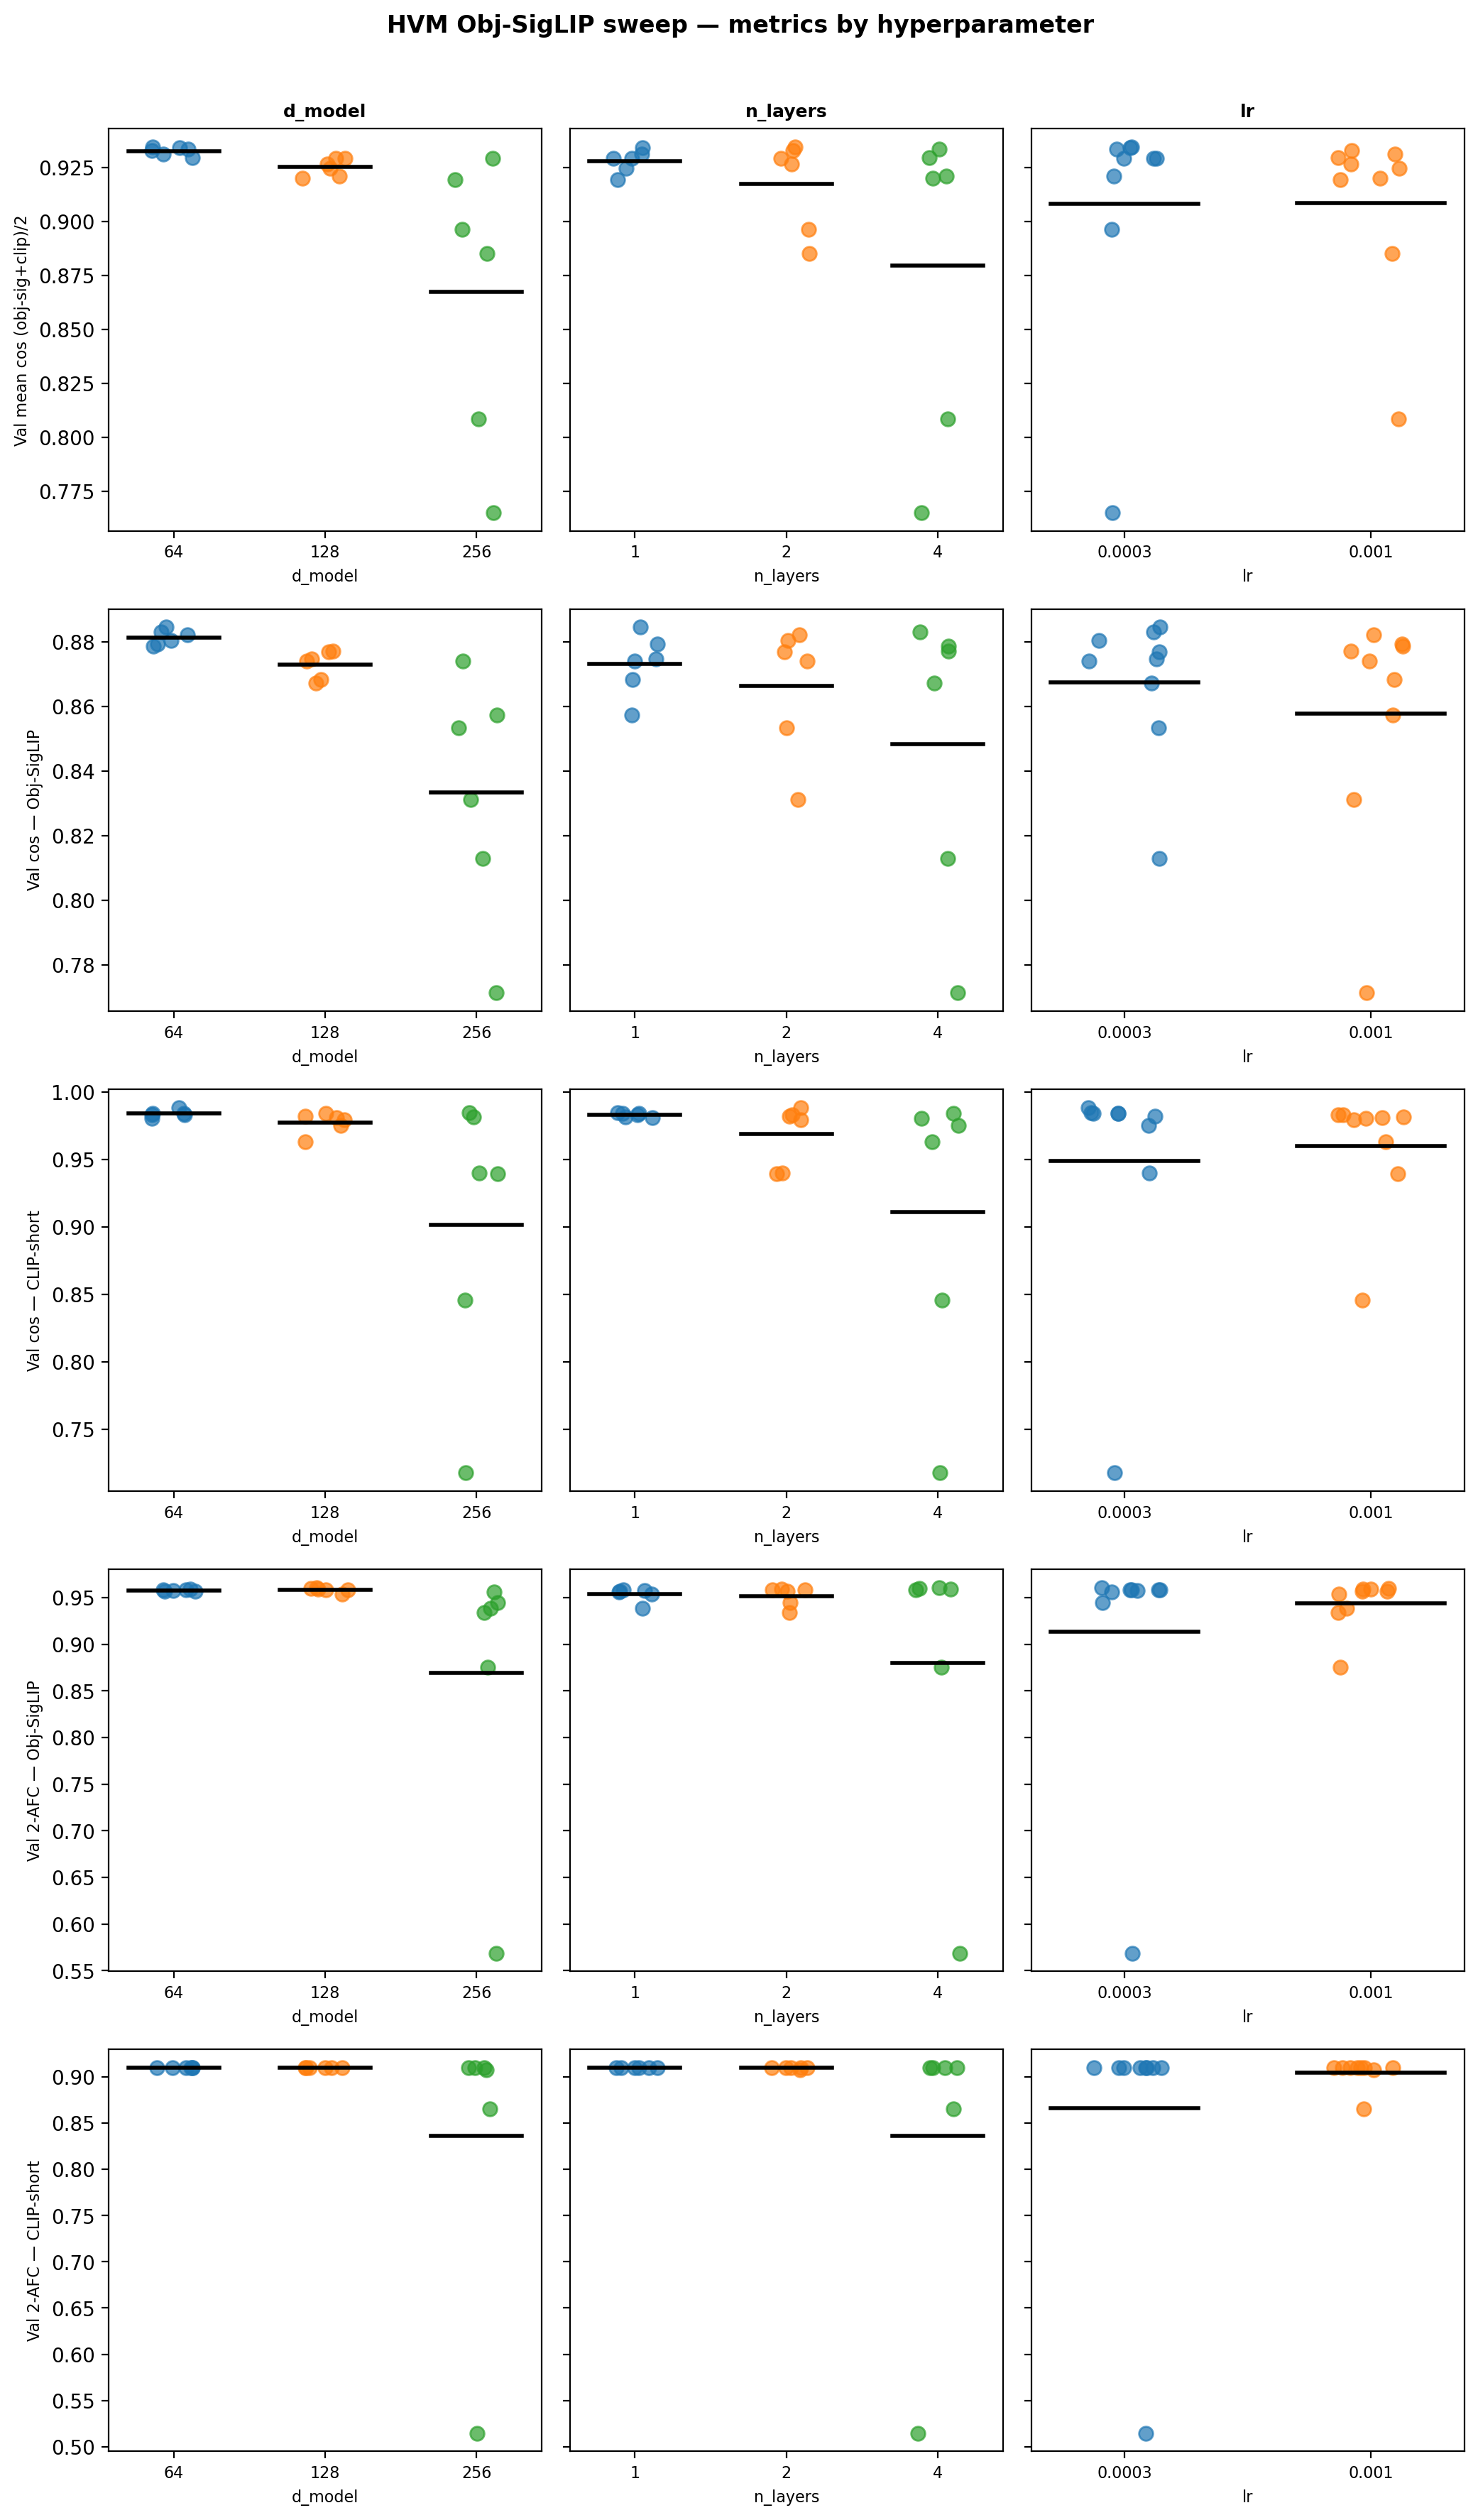

In [2]:
if df.empty:
    print('No runs yet.')
else:
    METRICS = [
        ('val_mean_cos',    'Val mean cos (obj-sig+clip)/2'),
        ('val_cos_siglip',  'Val cos — Obj-SigLIP'),
        ('val_cos_clip',    'Val cos — CLIP-short'),
        ('val_2afc_siglip', 'Val 2-AFC — Obj-SigLIP'),
        ('val_2afc_clip',   'Val 2-AFC — CLIP-short'),
    ]
    
    fig, axes = plt.subplots(len(METRICS), len(SWEEP_AXES),
                             figsize=(3.5 * len(SWEEP_AXES), 3.5 * len(METRICS)),
                             sharey='row', squeeze=False)
    rng = np.random.default_rng(0)
    
    for mi, (metric, ylabel) in enumerate(METRICS):
        if metric not in df.columns:
            continue
        for ai, axis_col in enumerate(SWEEP_AXES):
            ax = axes[mi, ai]
            if axis_col not in df.columns:
                ax.axis('off'); continue
            levels = sorted(df[axis_col].unique())
            for li, lvl in enumerate(levels):
                vals = df[df[axis_col] == lvl][metric].dropna().values
                jitter = rng.uniform(-0.15, 0.15, len(vals))
                ax.scatter(np.full(len(vals), li) + jitter, vals,
                           alpha=0.7, s=50, color=f'C{li}')
                if len(vals):
                    ax.plot([li - 0.3, li + 0.3], [vals.mean()] * 2, 'k-', lw=2)
            ax.set_xticks(range(len(levels)))
            ax.set_xticklabels([str(l) for l in levels], fontsize=8)
            ax.set_xlabel(axis_col, fontsize=8)
            if ai == 0:
                ax.set_ylabel(ylabel, fontsize=8)
            if mi == 0:
                ax.set_title(axis_col, fontsize=9, fontweight='bold')
    
    fig.suptitle('HVM Obj-SigLIP sweep — metrics by hyperparameter', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## Val vs test generalisation

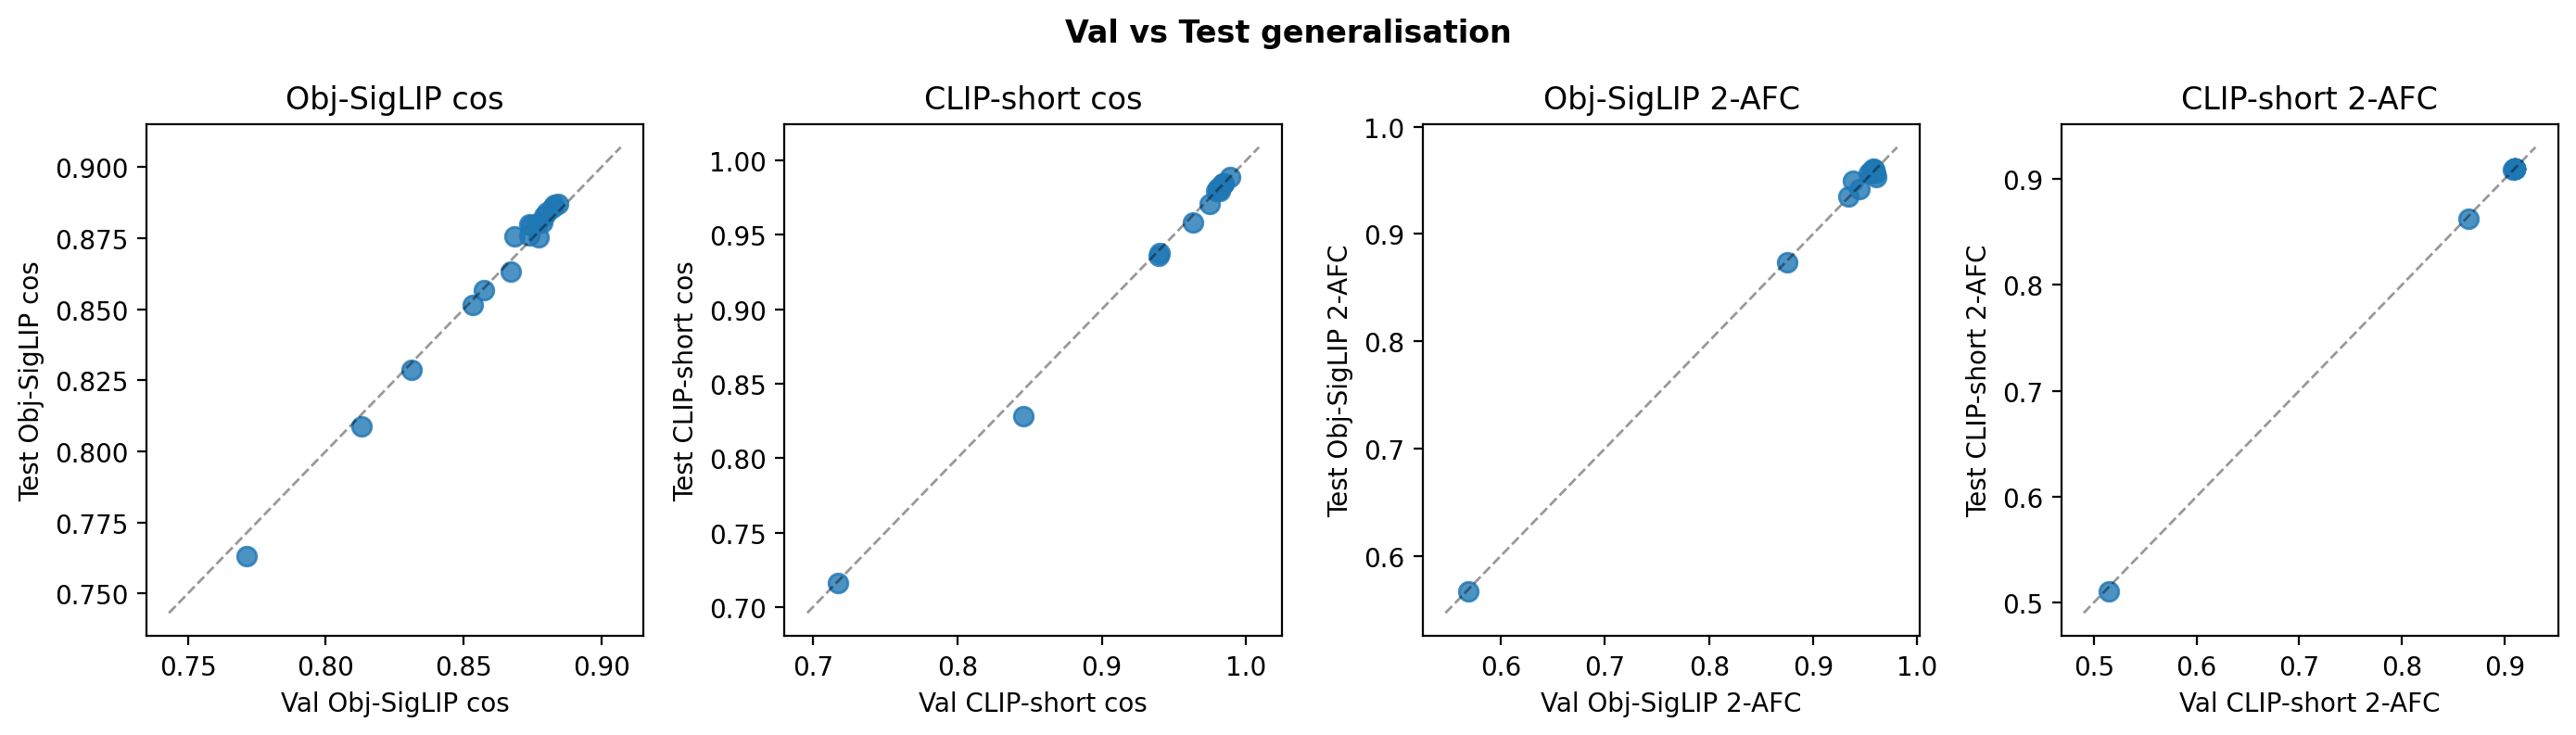

In [3]:
if df.empty:
    print('No runs yet.')
else:
    if has_test:
        pairs = [('val_cos_siglip',   'test_cos_siglip',   'Obj-SigLIP cos'),
                 ('val_cos_clip',     'test_cos_clip',     'CLIP-short cos'),
                 ('val_2afc_siglip',  'test_2afc_siglip',  'Obj-SigLIP 2-AFC'),
                 ('val_2afc_clip',    'test_2afc_clip',    'CLIP-short 2-AFC')]
        fig, axes = plt.subplots(1, 4, figsize=(14, 4))
        for ax, (vcol, tcol, title) in zip(axes, pairs):
            sub = df.dropna(subset=[vcol, tcol])
            ax.scatter(sub[vcol], sub[tcol], s=55, alpha=0.8)
            lim = [min(sub[vcol].min(), sub[tcol].min()) - 0.02,
                   max(sub[vcol].max(), sub[tcol].max()) + 0.02]
            ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
            ax.set_xlabel(f'Val {title}'); ax.set_ylabel(f'Test {title}')
            ax.set_title(title)
        fig.suptitle('Val vs Test generalisation', fontweight='bold')
        plt.tight_layout(); plt.show()
    else:
        print('Test metrics not yet available — rerun once all jobs complete.')

## Top-10 runs

In [4]:
if df.empty:
    print('No runs yet.')
else:
    top_cols = [c for c in
        ['d_model', 'n_layers', 'lr', 'epoch',
         'val_mean_cos', 'val_cos_siglip', 'val_cos_clip',
         'val_2afc_siglip', 'val_2afc_clip',
         'test_cos_siglip', 'test_cos_clip',
         'test_2afc_siglip', 'test_2afc_clip', 'path']
        if c in df.columns]
    display(df.sort_values('val_mean_cos', ascending=False)[top_cols].head(10).reset_index(drop=True))

,d_model,n_layers,lr,epoch,val_mean_cos,val_cos_siglip,val_cos_clip,val_2afc_siglip,val_2afc_clip,test_cos_siglip,test_cos_clip,test_2afc_siglip,test_2afc_clip,path
0,64,2,0.0003,133,0.934491,0.880366,0.988617,0.958177,0.910112,0.884038,0.988879,0.959176,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
1,64,1,0.0003,79,0.934228,0.884435,0.984021,0.957803,0.910112,0.887039,0.984388,0.959176,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
2,64,4,0.0003,106,0.933462,0.882888,0.984036,0.958177,0.910112,0.886893,0.984090,0.960175,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
3,64,2,0.0010,38,0.932764,0.882204,0.983323,0.957054,0.910112,0.885715,0.983455,0.959176,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
4,64,1,0.0010,38,0.931282,0.879205,0.983360,0.956804,0.910112,0.882990,0.983335,0.958677,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
5,64,4,0.0010,42,0.929496,0.878542,0.980449,0.958926,0.910112,0.880417,0.979875,0.958552,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
6,128,1,0.0003,73,0.929454,0.874624,0.984284,0.958177,0.910112,0.879547,0.984470,0.958052,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
7,128,2,0.0003,91,0.929401,0.876755,0.982046,0.958052,0.910112,0.880241,0.981545,0.960549,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
8,256,1,0.0003,96,0.929292,0.874027,0.984558,0.955805,0.910112,0.879779,0.984239,0.959301,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
9,128,2,0.0010,39,0.926722,0.873886,0.979559,0.959176,0.910112,0.875938,0.979442,0.960175,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...


## Save best obj-SigLIP config

In [5]:
if df.empty:
    print('No runs yet — nothing to save.')
else:
    import json
    
    best_row = df.sort_values('val_mean_cos', ascending=False).iloc[0]
    config = {
        'model': 'multihead_obj',
        'dataset': 'hvm',
        'use_category': True,
        'val_mean_cos':    float(best_row['val_mean_cos']),
        'val_cos_siglip':  float(best_row['val_cos_siglip']),
        'val_cos_clip':    float(best_row['val_cos_clip']),
        'checkpoint': best_row['path'],
        'd_model':    int(best_row['d_model']),
        'n_heads':    int(best_row['n_heads']),
        'n_layers':   int(best_row['n_layers']),
        'shared_dim': int(best_row['shared_dim']),
        'dropout':    float(best_row['dropout']),
        'lr':         float(best_row['lr']),
        'weight_decay': float(best_row['weight_decay']),
    }
    
    out_path = CACHE_DIR / 'best_hvm_multihead_obj_config.json'
    with open(out_path, 'w') as f:
        json.dump(config, f, indent=2)
    
    print(f'Saved → {out_path}')
    print(f"  val_mean_cos={config['val_mean_cos']:.4f}")
    print(f"  val_cos_siglip={config['val_cos_siglip']:.4f}  val_cos_clip={config['val_cos_clip']:.4f}")
    print(f"  {config['checkpoint']}")

Saved → /home/yy3658/NeurObjectGen/cache/best_hvm_multihead_obj_config.json
  val_mean_cos=0.9345
  val_cos_siglip=0.8804  val_cos_clip=0.9886
  /home/yy3658/NeurObjectGen/checkpoints/multihead/hvm_obj_cat/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs64_ws5.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt


## Best config — all 4 metrics

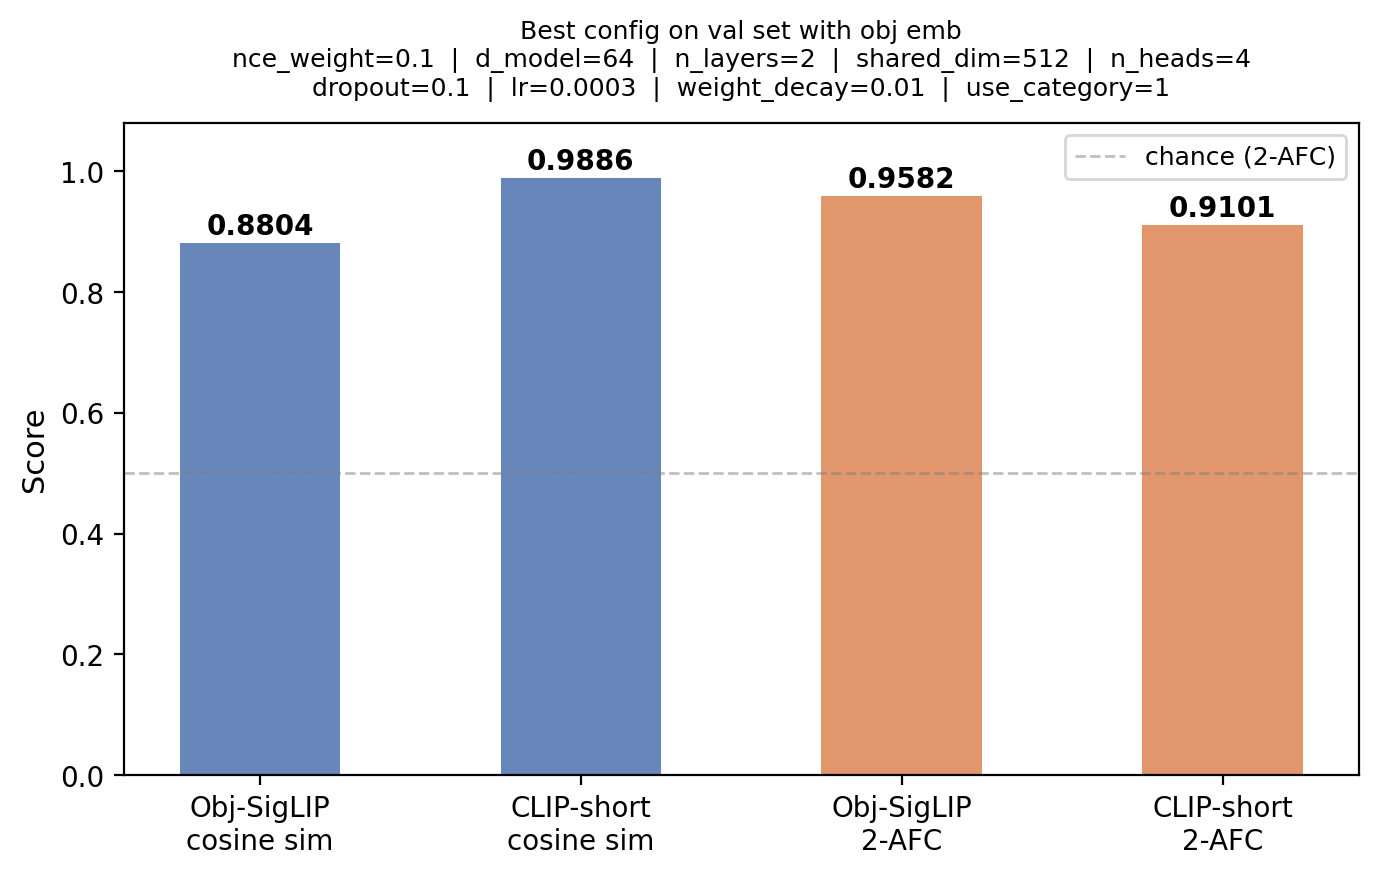

In [9]:
if not df.empty:
    BEST_METRICS = [
        ('val_cos_siglip',  'Obj-SigLIP\ncosine sim'),
        ('val_cos_clip',    'CLIP-short\ncosine sim'),
        ('val_2afc_siglip', 'Obj-SigLIP\n2-AFC'),
        ('val_2afc_clip',   'CLIP-short\n2-AFC'),
    ]

    best_row = df.sort_values('val_mean_cos', ascending=False).iloc[0]

    vals   = [float(best_row[m]) for m, _ in BEST_METRICS]
    labels = [l for _, l in BEST_METRICS]
    colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5, label='chance (2-AFC)')
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('Score', fontsize=11)
    ax.legend(fontsize=9)

    def _fmt(k, row):
        v = row[k]
        return f'{k}={int(v) if float(v) == int(float(v)) else v:.4g}'

    hp_line1 = '  |  '.join(_fmt(k, best_row) for k in ['nce_weight', 'd_model', 'n_layers', 'shared_dim', 'n_heads']
                             if k in best_row)
    hp_line2 = '  |  '.join(_fmt(k, best_row) for k in ['dropout', 'lr', 'weight_decay', 'use_category']
                             if k in best_row)
    ax.set_title(f'Best config on val set with obj emb\n{hp_line1}\n{hp_line2}', fontsize=9, pad=10)
    plt.tight_layout()
    plt.show()
